In [41]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import re


import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
from nltk.util import ngrams

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [2]:
customer_data = pd.read_csv('../data/raw/customer_support_tickets.csv')

In [3]:
print(customer_data.shape)

(8469, 17)


In [4]:
customer_data.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='str')

In [5]:
customer_data.dtypes

Ticket ID                         int64
Customer Name                       str
Customer Email                      str
Customer Age                      int64
Customer Gender                     str
Product Purchased                   str
Date of Purchase                    str
Ticket Type                         str
Ticket Subject                      str
Ticket Description                  str
Ticket Status                       str
Resolution                          str
Ticket Priority                     str
Ticket Channel                      str
First Response Time                 str
Time to Resolution                  str
Customer Satisfaction Rating    float64
dtype: object

In [6]:
customer_data.isnull().sum()

Ticket ID                          0
Customer Name                      0
Customer Email                     0
Customer Age                       0
Customer Gender                    0
Product Purchased                  0
Date of Purchase                   0
Ticket Type                        0
Ticket Subject                     0
Ticket Description                 0
Ticket Status                      0
Resolution                      5700
Ticket Priority                    0
Ticket Channel                     0
First Response Time             2819
Time to Resolution              5700
Customer Satisfaction Rating    5700
dtype: int64

In [7]:
customer_data.duplicated().sum()

np.int64(0)

In [8]:
text_columns = ["Ticket Subject", "Ticket Description"]
print(customer_data[text_columns].isnull().sum())

Ticket Subject        0
Ticket Description    0
dtype: int64


In [9]:
customer_data["text"] = (
    customer_data["Ticket Subject"].astype(str) + " " +
    customer_data["Ticket Description"].astype(str)
)

customer_data[["Ticket Subject", "Ticket Description", "text"]].head()

,Ticket Subject,Ticket Description,text
0,Product setup,I'm having an issue with the {product_purchase...,Product setup I'm having an issue with the {pr...
1,Peripheral compatibility,I'm having an issue with the {product_purchase...,Peripheral compatibility I'm having an issue w...
2,Network problem,I'm facing a problem with my {product_purchase...,Network problem I'm facing a problem with my {...
3,Account access,I'm having an issue with the {product_purchase...,Account access I'm having an issue with the {p...
4,Data loss,I'm having an issue with the {product_purchase...,Data loss I'm having an issue with the {produc...


In [10]:
print("Total records:", len(customer_data))
print("Empty text records:", (customer_data["text"].str.strip() == "").sum())

Total records: 8469
Empty text records: 0


In [11]:
def clean_text(text):
    text = str(text).lower()

    # Replace product placeholder
    text = text.replace("{product_purchased}", "product")

    # Remove email addresses
    text = re.sub(r'\S+@\S+', ' ', text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # Remove phone numbers
    text = re.sub(r'\b\d[\d\-\(\) ]{7,}\b', ' ', text)

    # Keep only letters and spaces
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [12]:
customer_data["clean_text"] = customer_data["text"].apply(clean_text)

In [13]:
customer_data[["text", "clean_text"]].head(10)

,text,clean_text
0,Product setup I'm having an issue with the {pr...,product setup i m having an issue with the pro...
1,Peripheral compatibility I'm having an issue w...,peripheral compatibility i m having an issue w...
2,Network problem I'm facing a problem with my {...,network problem i m facing a problem with my p...
3,Account access I'm having an issue with the {p...,account access i m having an issue with the pr...
4,Data loss I'm having an issue with the {produc...,data loss i m having an issue with the product...
5,Payment issue I'm facing a problem with my {pr...,payment issue i m facing a problem with my pro...
6,Refund request I'm unable to access my {produc...,refund request i m unable to access my product...
7,Battery life I'm having an issue with the {pro...,battery life i m having an issue with the prod...
8,Installation support I'm having an issue with ...,installation support i m having an issue with ...
9,Payment issue My {product_purchased} is making...,payment issue my product is making strange noi...


In [14]:
customer_data["text_length"] = (
    customer_data["clean_text"].str.split().str.len()
)
print(customer_data["text_length"].describe())

count    8469.000000
mean       50.593222
std         8.808904
min        25.000000
25%        46.000000
50%        53.000000
75%        57.000000
max        66.000000
Name: text_length, dtype: float64


In [15]:
customer_data["Ticket Type"].value_counts()

Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64

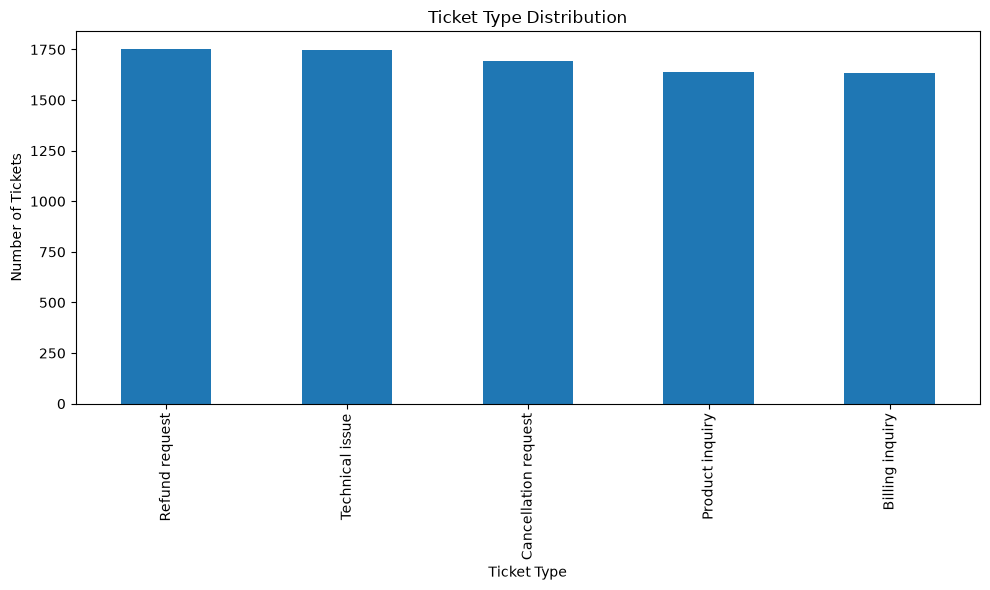

In [16]:
ticket_type_counts = customer_data["Ticket Type"].value_counts()

plt.figure(figsize=(10, 6))
ticket_type_counts.plot(kind="bar")
plt.title("Ticket Type Distribution")
plt.xlabel("Ticket Type")
plt.ylabel("Number of Tickets")
plt.tight_layout()
plt.show()

In [17]:
nlp_data = customer_data[["clean_text", "Ticket Type"]].copy()

In [18]:
nlp_data = nlp_data.rename(columns={"clean_text": "text", "Ticket Type": "label"})
print("NLP Dataset Shape:", nlp_data.shape)
nlp_data.head()

NLP Dataset Shape: (8469, 2)


,text,label
0,product setup i m having an issue with the pro...,Technical issue
1,peripheral compatibility i m having an issue w...,Technical issue
2,network problem i m facing a problem with my p...,Technical issue
3,account access i m having an issue with the pr...,Billing inquiry
4,data loss i m having an issue with the product...,Billing inquiry


In [19]:
print(nlp_data["label"].value_counts())

label
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


In [20]:
from sklearn.model_selection import train_test_split

X = nlp_data["text"]
y = nlp_data["label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 6775
Validation samples: 847
Test samples: 847


In [21]:
print("Train distribution:")
print(y_train.value_counts())

print("\nValidation distribution:")
print(y_val.value_counts())

print("\nTest distribution:")
print(y_test.value_counts())

Train distribution:
label
Refund request          1401
Technical issue         1398
Cancellation request    1356
Product inquiry         1313
Billing inquiry         1307
Name: count, dtype: int64

Validation distribution:
label
Refund request          175
Technical issue         175
Cancellation request    170
Product inquiry         164
Billing inquiry         163
Name: count, dtype: int64

Test distribution:
label
Refund request          176
Technical issue         174
Cancellation request    169
Billing inquiry         164
Product inquiry         164
Name: count, dtype: int64


In [22]:
nlp_data.to_csv("../data/processed/customer_support_nlp_cleaned.csv", index=False)
print("saved")

saved


In [23]:
train_data = pd.DataFrame({
    "text": X_train,
    "label": y_train
})

val_data = pd.DataFrame({
    "text": X_val,
    "label": y_val
})

test_data = pd.DataFrame({
    "text": X_test,
    "label": y_test
})

train_data.to_csv(
    "../data/processed/nlp_train.csv",
    index=False
)

val_data.to_csv(
    "../data/processed/nlp_validation.csv",
    index=False
)

test_data.to_csv(
    "../data/processed/nlp_test.csv",
    index=False
)

print("Train, validation, and test datasets saved successfully.")

Train, validation, and test datasets saved successfully.


### Stop word handling

In [24]:
nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\SURYA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\SURYA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SURYA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [25]:
customer_data["tokens"] = customer_data["clean_text"].apply(word_tokenize)
customer_data[["clean_text", "tokens"]].head()

,clean_text,tokens
0,product setup i m having an issue with the pro...,"[product, setup, i, m, having, an, issue, with..."
1,peripheral compatibility i m having an issue w...,"[peripheral, compatibility, i, m, having, an, ..."
2,network problem i m facing a problem with my p...,"[network, problem, i, m, facing, a, problem, w..."
3,account access i m having an issue with the pr...,"[account, access, i, m, having, an, issue, wit..."
4,data loss i m having an issue with the product...,"[data, loss, i, m, having, an, issue, with, th..."


In [26]:
customer_data["token_count"] = customer_data["tokens"].apply(len)
print(customer_data["token_count"].describe())

count    8469.000000
mean       50.604794
std         8.812085
min        25.000000
25%        46.000000
50%        53.000000
75%        57.000000
max        66.000000
Name: token_count, dtype: float64


In [27]:
stop_words = set(stopwords.words("english"))

# Keep important negation words
negation_words = {
    "no", "not", "nor", "never",
    "neither", "none", "nothing",
    "without", "hardly", "barely"
}

stop_words = stop_words - negation_words

print("Total stop words:", len(stop_words))
print("Preserved words:", sorted(negation_words))

Total stop words: 195
Preserved words: ['barely', 'hardly', 'neither', 'never', 'no', 'none', 'nor', 'not', 'nothing', 'without']


In [28]:
customer_data["tokens_no_stopwords"] = customer_data["tokens"].apply(
    lambda tokens: [word for word in tokens if word not in stop_words
    ])

In [29]:
customer_data["token_count_no_stopwords"] = (customer_data["tokens_no_stopwords"].apply(len))
print(customer_data["token_count_no_stopwords"].describe())

count    8469.000000
mean       25.004723
std         4.235897
min        12.000000
25%        23.000000
50%        26.000000
75%        28.000000
max        47.000000
Name: token_count_no_stopwords, dtype: float64


### Word frequency analysis

In [31]:
all_words = [word for tokens in customer_data["tokens_no_stopwords"] for word in tokens]

word_frequency = Counter(all_words)
word_freq_df = pd.DataFrame(word_frequency.most_common(20), columns=["Word", "Frequency"])
word_freq_df

,Word,Frequency
0,product,18588
1,issue,13083
2,please,8815
3,assist,6258
4,problem,3385
5,not,2379
6,data,2158
7,software,2129
8,account,1977
9,support,1470


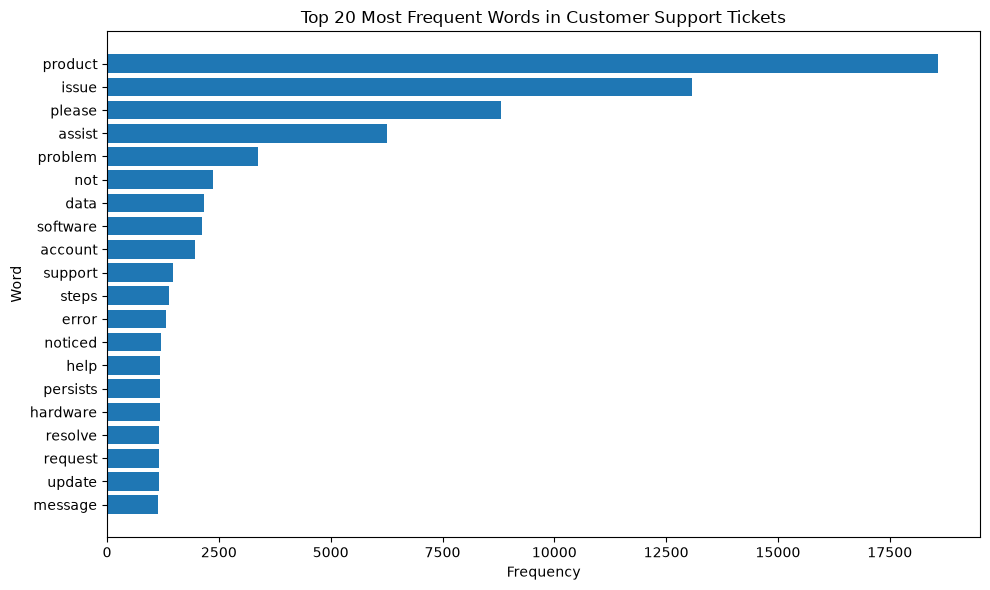

In [32]:
plt.figure(figsize=(10, 6))
plt.barh(word_freq_df["Word"][::-1], word_freq_df["Frequency"][::-1])
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.title("Top 20 Most Frequent Words in Customer Support Tickets")
plt.tight_layout()
plt.show()

### N-gram Analysis

In [33]:
all_tokens = [word for tokens in customer_data["tokens_no_stopwords"] for word in tokens]

bigrams = list(ngrams(all_tokens, 2))
bigram_frequency = Counter(bigrams)

bigram_freq_df = pd.DataFrame(bigram_frequency.most_common(20), columns=["Bigram", "Frequency"])
bigram_freq_df["Bigram"] = bigram_freq_df["Bigram"].apply(lambda x: " ".join(x))
bigram_freq_df

,Bigram,Frequency
0,issue product,6428
1,please assist,6247
2,product please,6169
3,issue persists,1176
4,issue issue,1106
5,product issue,1015
6,error message,972
7,software bug,942
8,data loss,852
9,battery life,831


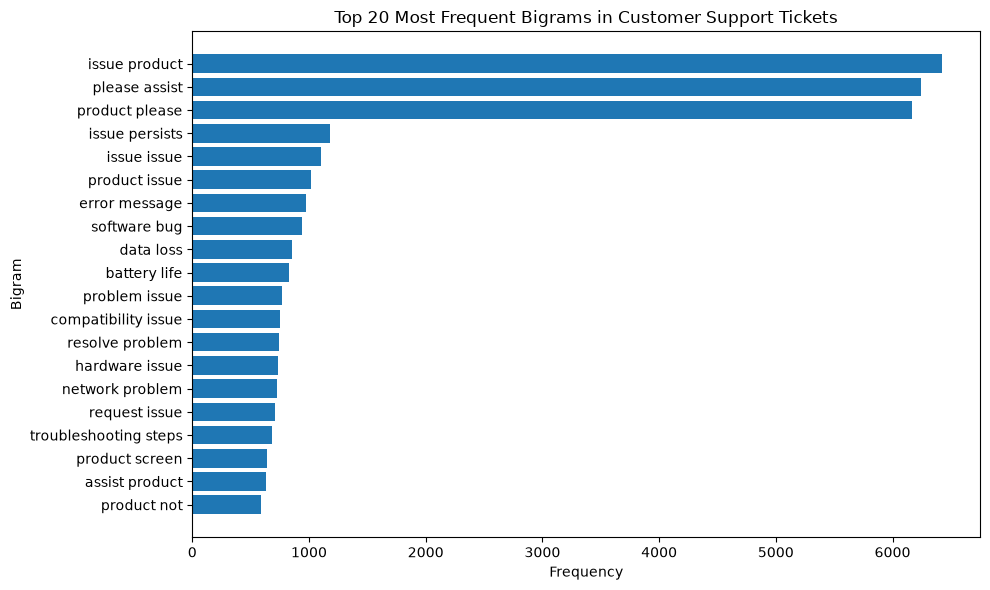

In [34]:
# biagrams chart

plt.figure(figsize=(10, 6))
plt.barh(bigram_freq_df["Bigram"][::-1], bigram_freq_df["Frequency"][::-1])
plt.xlabel("Frequency")
plt.ylabel("Bigram")
plt.title("Top 20 Most Frequent Bigrams in Customer Support Tickets")
plt.tight_layout()
plt.show()

In [35]:
trigrams = list(ngrams(all_tokens, 3))

trigram_frequency = Counter(trigrams)
trigram_freq_df = pd.DataFrame(trigram_frequency.most_common(20), columns=["Trigram", "Frequency"])

trigram_freq_df["Trigram"] = trigram_freq_df["Trigram"].apply(lambda x: " ".join(x))
trigram_freq_df

,Trigram,Frequency
0,product please assist,6095
1,issue product please,6037
2,issue issue product,1091
3,problem issue product,763
4,compatibility issue product,749
5,request issue product,708
6,please assist product,629
7,data loss issue,506
8,loss issue product,502
9,software updates product,502


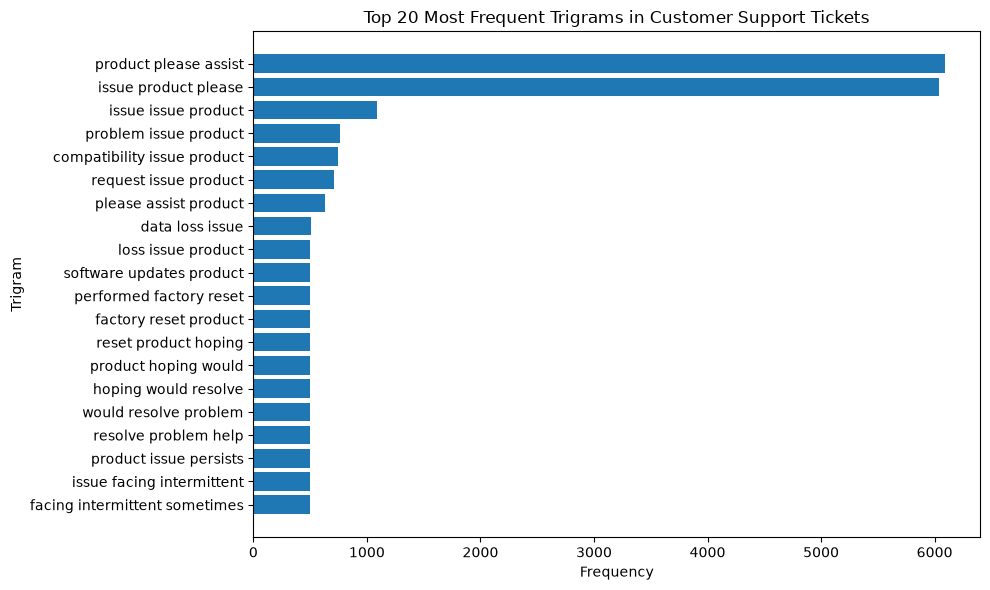

In [36]:
# trigram chart

plt.figure(figsize=(10, 6))
plt.barh(trigram_freq_df["Trigram"][::-1], trigram_freq_df["Frequency"][::-1])
plt.xlabel("Frequency")
plt.ylabel("Trigram")
plt.title("Top 20 Most Frequent Trigrams in Customer Support Tickets")
plt.tight_layout()
plt.show()

In [37]:
word_freq_df.to_csv("../data/processed/word_frequency.csv", index=False)
bigram_freq_df.to_csv("../data/processed/bigram_frequency.csv", index=False)
trigram_freq_df.to_csv("../data/processed/trigram_frequency.csv", index=False)

print('saved')

saved


In [38]:
customer_data["processed_text"] = customer_data["tokens_no_stopwords"].apply(lambda tokens: " ".join(tokens))

customer_data[["clean_text", "processed_text", "Ticket Type"]].head()

,clean_text,processed_text,Ticket Type
0,product setup i m having an issue with the pro...,product setup issue product please assist bill...,Technical issue
1,peripheral compatibility i m having an issue w...,peripheral compatibility issue product please ...,Technical issue
2,network problem i m facing a problem with my p...,network problem facing problem product product...,Technical issue
3,account access i m having an issue with the pr...,account access issue product please assist pro...,Billing inquiry
4,data loss i m having an issue with the product...,data loss issue product please assist note sel...,Billing inquiry


In [40]:
nlp_processed_data = customer_data[["processed_text", "Ticket Type"]].copy()
nlp_processed_data = nlp_processed_data.rename(columns={"processed_text": "text", "Ticket Type": "label"})

nlp_processed_data.to_csv("../data/processed/customer_support_nlp_final.csv", index=False)

print("Final NLP dataset saved successfully.")
print("Records:", len(nlp_processed_data))

Final NLP dataset saved successfully.
Records: 8469


## TF-IDF

In [42]:
print("Dataset shape:", customer_data.shape)

Dataset shape: (8469, 25)


In [43]:
print(customer_data.columns.tolist())

['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating', 'text', 'clean_text', 'text_length', 'tokens', 'token_count', 'tokens_no_stopwords', 'token_count_no_stopwords', 'processed_text']


In [45]:
print(customer_data["clean_text"].isnull().sum())
print(customer_data["Ticket Type"].isnull().sum())
print(customer_data["Ticket Type"].value_counts())

0
0
Ticket Type
Refund request          1752
Technical issue         1747
Cancellation request    1695
Product inquiry         1641
Billing inquiry         1634
Name: count, dtype: int64


In [46]:
nlp_data = customer_data[["clean_text", "Ticket Type"]].copy()

In [47]:
nlp_data = nlp_data.rename(
    columns={"clean_text": "text", "Ticket Type": "label"}
)
print("NLP dataset shape:", nlp_data.shape)
nlp_data.head()

NLP dataset shape: (8469, 2)


,text,label
0,product setup i m having an issue with the pro...,Technical issue
1,peripheral compatibility i m having an issue w...,Technical issue
2,network problem i m facing a problem with my p...,Technical issue
3,account access i m having an issue with the pr...,Billing inquiry
4,data loss i m having an issue with the product...,Billing inquiry


In [48]:
X = nlp_data["text"]
y = nlp_data["label"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training samples  :", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples      :", len(X_test))

Training samples  : 6775
Validation samples: 847
Test samples      : 847


In [50]:
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

print("created successfully")

created successfully


In [51]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

X_val_tfidf = tfidf_vectorizer.transform(X_val)

X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Training TF-IDF shape  :", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape      :", X_test_tfidf.shape)

Training TF-IDF shape  : (6775, 10000)
Validation TF-IDF shape: (847, 10000)
Test TF-IDF shape      : (847, 10000)


In [52]:
logistic_tfidf = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_tfidf.fit(
    X_train_tfidf,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [53]:
y_val_pred_lr = logistic_tfidf.predict(
    X_val_tfidf
)

In [54]:
print("Number of predictions:", len(y_val_pred_lr))

Number of predictions: 847


In [57]:
lr_accuracy = accuracy_score(
    y_val,
    y_val_pred_lr
)

lr_precision = precision_score(
    y_val,
    y_val_pred_lr,
    average="weighted",
    zero_division=0
)

lr_recall = recall_score(
    y_val,
    y_val_pred_lr,
    average="weighted",
    zero_division=0
)

lr_f1 = f1_score(
    y_val,
    y_val_pred_lr,
    average="weighted",
    zero_division=0
)

print("Logistic Regression - TF-IDF")
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}")

Logistic Regression - TF-IDF
Accuracy : 0.1913
Precision: 0.1908
Recall   : 0.1913
F1 Score : 0.1909


In [58]:
print(
    classification_report(
        y_val,
        y_val_pred_lr,
        zero_division=0
    )
)

                      precision    recall  f1-score   support

     Billing inquiry       0.15      0.14      0.14       163
Cancellation request       0.14      0.14      0.14       170
     Product inquiry       0.23      0.22      0.23       164
      Refund request       0.21      0.23      0.22       175
     Technical issue       0.22      0.22      0.22       175

            accuracy                           0.19       847
           macro avg       0.19      0.19      0.19       847
        weighted avg       0.19      0.19      0.19       847



### Naive Bayes

In [59]:
naive_bayes_tfidf = MultinomialNB()

naive_bayes_tfidf.fit(
    X_train_tfidf,
    y_train
)


,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](5,)","[1307.,1356.,1313.,1401.,1398.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](5,)","[-1.65,-1.61,-1.64,-1.58,-1.58]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U20](5,)","['Billing inquiry','Cancellation request','Product inquiry', 'Refund request','Technical issue']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](5, 10000)","[[0.19,0.19,3.51,...,0.57,0. ,0. ], [0.2 ,0.2 ,3.63,...,0. ,0.28,0. ], [0.23,0. ,2.29,...,0.41,0. ,0.26], [0.19,0.2 ,3.02,...,0.2 ,0.26,0. ], [0. ,0. ,2.36,...,0.32,0. ,0.43]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](5, 10000)","[[-9.73,-9.73,-8.4 ,...,-9.45,-9.9 ,-9.9 ], [-9.74,-9.73,-8.39,...,-9.92,-9.67,-9.92], [-9.69,-9.9 ,-8.71,...,-9.56,-9.9 ,-9.68], [-9.76,-9.76,-8.55,...,-9.75,-9.7 ,-9.94], [-9.93,-9.93,-8.72,...,-9.65,-9.93,-9.58]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10000


In [61]:
y_val_pred_nb = naive_bayes_tfidf.predict(
    X_val_tfidf
)
print("Number of predictions:", len(y_val_pred_nb))

Number of predictions: 847


In [62]:
nb_accuracy = accuracy_score(
    y_val,
    y_val_pred_nb
)

nb_precision = precision_score(
    y_val,
    y_val_pred_nb,
    average="weighted",
    zero_division=0
)

nb_recall = recall_score(
    y_val,
    y_val_pred_nb,
    average="weighted",
    zero_division=0
)

nb_f1 = f1_score(
    y_val,
    y_val_pred_nb,
    average="weighted",
    zero_division=0
)

print("Naive Bayes - TF-IDF")
print("=" * 40)
print(f"Accuracy : {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall   : {nb_recall:.4f}")
print(f"F1 Score : {nb_f1:.4f}")

Naive Bayes - TF-IDF
Accuracy : 0.1889
Precision: 0.1816
Recall   : 0.1889
F1 Score : 0.1816


In [63]:
print(
    classification_report(
        y_val,
        y_val_pred_nb,
        zero_division=0
    )
)

                      precision    recall  f1-score   support

     Billing inquiry       0.14      0.09      0.11       163
Cancellation request       0.16      0.16      0.16       170
     Product inquiry       0.17      0.13      0.15       164
      Refund request       0.21      0.30      0.25       175
     Technical issue       0.22      0.26      0.24       175

            accuracy                           0.19       847
           macro avg       0.18      0.19      0.18       847
        weighted avg       0.18      0.19      0.18       847



In [64]:
tfidf_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes"
    ],
    "Accuracy": [
        lr_accuracy,
        nb_accuracy
    ],
    "Precision": [
        lr_precision,
        nb_precision
    ],
    "Recall": [
        lr_recall,
        nb_recall
    ],
    "F1 Score": [
        lr_f1,
        nb_f1
    ]
})

tfidf_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.191263,0.190777,0.191263,0.190867
1,Naive Bayes,0.188902,0.181566,0.188902,0.181630


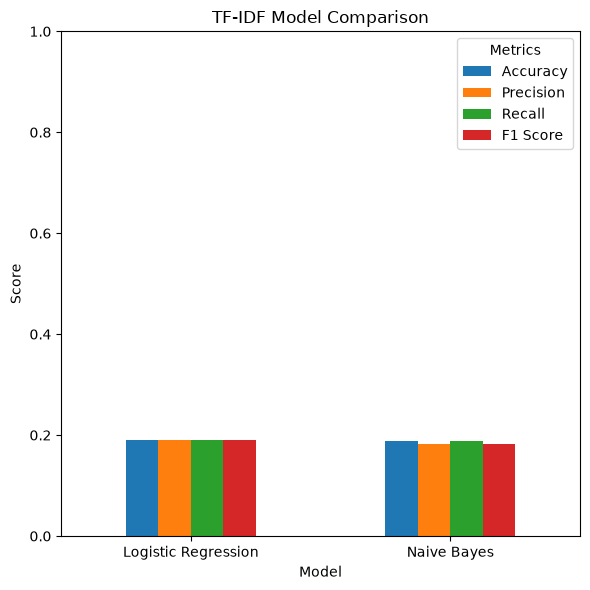

In [67]:
tfidf_results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(
    kind="bar", figsize=(6, 6))

plt.title("TF-IDF Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrics")
plt.tight_layout()
plt.show()

In [68]:
best_tfidf_model = logistic_tfidf

print("Selected TF-IDF Model: Logistic Regression")
print(f"Validation Accuracy: {lr_accuracy:.4f}")
print(f"Validation F1 Score: {lr_f1:.4f}")

Selected TF-IDF Model: Logistic Regression
Validation Accuracy: 0.1913
Validation F1 Score: 0.1909


In [70]:
y_test_pred_lr = best_tfidf_model.predict(
    X_test_tfidf
)

print("Number of test predictions:", len(y_test_pred_lr))

Number of test predictions: 847


In [71]:
test_accuracy = accuracy_score(
    y_test,
    y_test_pred_lr
)

test_precision = precision_score(
    y_test,
    y_test_pred_lr,
    average="weighted",
    zero_division=0
)

test_recall = recall_score(
    y_test,
    y_test_pred_lr,
    average="weighted",
    zero_division=0
)

test_f1 = f1_score(
    y_test,
    y_test_pred_lr,
    average="weighted",
    zero_division=0
)

print("Final Logistic Regression - TF-IDF Test Results")

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1 Score : {test_f1:.4f}")

Final Logistic Regression - TF-IDF Test Results
Accuracy : 0.2279
Precision: 0.2282
Recall   : 0.2279
F1 Score : 0.2275


In [72]:
print(
    classification_report(
        y_test,
        y_test_pred_lr,
        zero_division=0
    )
)

                      precision    recall  f1-score   support

     Billing inquiry       0.24      0.21      0.22       164
Cancellation request       0.23      0.25      0.24       169
     Product inquiry       0.21      0.20      0.20       164
      Refund request       0.25      0.26      0.25       176
     Technical issue       0.21      0.23      0.22       174

            accuracy                           0.23       847
           macro avg       0.23      0.23      0.23       847
        weighted avg       0.23      0.23      0.23       847



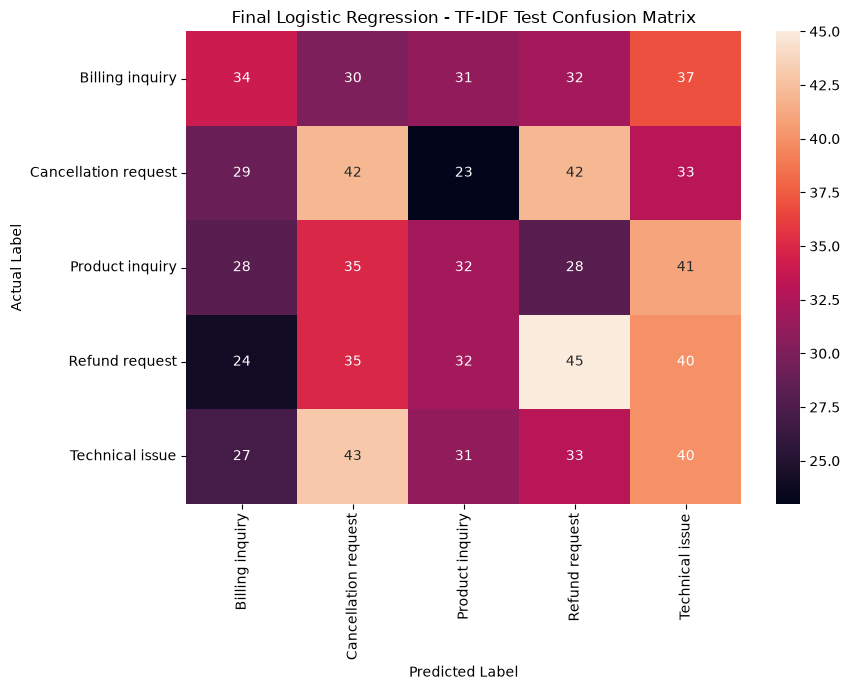

In [73]:
labels = sorted(y_test.unique())

cm_test_lr = confusion_matrix(y_test, y_test_pred_lr, labels=labels)
plt.figure(figsize=(9, 7))
sns.heatmap(cm_test_lr, annot=True, fmt="d", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Final Logistic Regression - TF-IDF Test Confusion Matrix")
plt.tight_layout()
plt.show()